# Superstore Business Analysis
**Role:** Data Analyst, B2B technology company (assessment context)  
**Dataset:** Sample Superstore — 9,994 US retail order lines, 2014–2017  
**Goal:** Identify business opportunities, performance gaps, and operational improvements for management.

This notebook covers dataset loading, cleaning (Q3), exploratory analysis (Q4/Q5), and the data-quality review (Q6). See the accompanying `Superstore_Assessment_Workbook.xlsx` for the full written answers to Q1–Q10.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
df = pd.read_csv('../data/superstore_raw.csv', encoding='latin1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Data Quality Check

In [2]:
print('Exact duplicate rows:', df.duplicated().sum())
print('Missing values per column:\n', df.isna().sum().sum(), 'total nulls')
print('Unique orders:', df['Order ID'].nunique(), '| Unique customers:', df['Customer ID'].nunique())
print('Duplicate Order+Product lines (legit re-orders):', df.duplicated(subset=['Order ID','Product ID']).sum())

Exact duplicate rows: 0
Missing values per column:
 0 total nulls
Unique orders: 5009 | Unique customers: 793
Duplicate Order+Product lines (legit re-orders): 8


## 2. Cleaning & Feature Engineering (Worksheet: Q3)

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1]
labels = ['0%','1-10%','11-20%','21-30%','31-50%','>50%']
df['Discount Band'] = pd.cut(df['Discount'], bins=bins, labels=labels)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

def flag_outlier(g):
    q1, q3 = g['Profit'].quantile([0.25, 0.75])
    iqr = q3 - q1
    return (g['Profit'] < q1 - 3*iqr) | (g['Profit'] > q3 + 3*iqr)

df['Profit Outlier'] = df.groupby('Sub-Category', group_keys=False).apply(flag_outlier)
print('Flagged rows (kept, for review):', df['Profit Outlier'].sum())
df.to_csv('../data/superstore_processed.csv', index=False)
df.head()

Flagged rows (kept, for review): 700


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Days,Margin %,Discount Band,Year,Month,Profit Outlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00,0%,2016,2016-11,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00,0%,2016,2016-11,False
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00,0%,2016,2016-06,False
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00,31-50%,2015,2015-10,False
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25,11-20%,2015,2015-10,False


## 3. Exploratory Analysis & Insights (Worksheet: Q4)

In [4]:
print('--- Region ---')
display(df.groupby('Region')[['Sales','Profit']].sum().assign(Margin=lambda d: (d.Profit/d.Sales*100).round(1)))
print('--- Category ---')
display(df.groupby('Category')[['Sales','Profit']].sum())
print('--- Sub-Category (sorted by Profit) ---')
display(df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Profit'))

--- Region ---


,Sales,Profit,Margin
Region,,,
Central,501239.8908,39706.3625,7.9
East,678781.2400,91522.7800,13.5
South,391721.9050,46749.4303,11.9
West,725457.8245,108418.4489,14.9


--- Category ---


,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


--- Sub-Category (sorted by Profit) ---


,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


In [5]:
band_stats = df.groupby('Discount Band', observed=True)[['Profit','Margin %']].mean()
print('Correlation, Discount vs Margin %:', df['Discount'].corr(df['Margin %']).round(3))
band_stats

Correlation, Discount vs Margin %: -0.864


,Profit,Margin %
Discount Band,,
0%,66.900292,34.016048
1-10%,96.055074,15.579468
11-20%,24.738824,17.483874
21-30%,-45.679636,-11.548414
31-50%,-156.282991,-29.606355
>50%,-89.438144,-113.878493


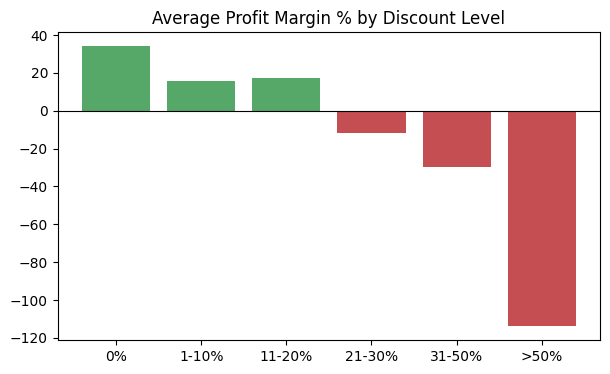

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
band = df.groupby('Discount Band', observed=True)['Margin %'].mean().reindex(labels)
colors = ['#55A868' if v>=0 else '#C44E52' for v in band.values]
ax.bar(band.index, band.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit Margin % by Discount Level')
plt.show()

## 4. Surprising Result (Worksheet: Q5)
Top customer by *sales* is not the top customer by *profit*.

In [7]:
cust = df.groupby(['Customer ID','Customer Name'])[['Sales','Profit']].sum()
print('Top 5 by Sales:')
display(cust.sort_values('Sales', ascending=False).head(5))
print('Top 5 by Profit:')
display(cust.sort_values('Profit', ascending=False).head(5))

Top 5 by Sales:


,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.050,-1980.7393
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
TA-21385,Tom Ashbrook,14595.620,4703.7883
AB-10105,Adrian Barton,14473.571,5444.8055


Top 5 by Profit:


,,Sales,Profit
Customer ID,Customer Name,,
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
AB-10105,Adrian Barton,14473.571,5444.8055


## 5. Data Quality Issues & Limitations (Worksheet: Q6)
- No cost/COGS data — Profit is taken as given.
- Raw Postal Code loses leading zeros on New England ZIPs (fixed above).
- No customer demographic/acquisition data.
- Data covers 2014–2017 only — over 8 years old relative to today.

See `Superstore_Assessment_Workbook.xlsx` (sheet Q6) for full detail, and sheets Q7 (recommendations), Q8 (dashboard), Q10 (AI usage).